Q1. 599개 공식 segment 각각에서도 AI2 ≈ 1.6~1.7초가 반복되는가?
Q2. 1.7초 후 신호가 원래 값으로 실제로 돌아오는가?
Q3. 0.5 / 0.8 / 1.0 / 2.0초와 비교해 1.7초가 특별한가?

# 05. EDA Cycle Candidate Validation

## 분석 목적

05_EDA_Cycle에서 AI2_Current에 약 1.6~1.7초의 안정적인 반복구조가 존재하고,
Peak-to-Peak 기준 475개의 Normal Cycle Candidate가 추출됨을 확인하였다.

본 Notebook에서는 같은 결론을 반복해서 시각화하는 대신,
공식 599개 Normal segment 각각에서도 해당 반복주기가 재현되는지 추가 검증한다.

검증 질문은 다음과 같다.

1. 각 Normal segment의 ACF에서도 약 1.6~1.7초 반복주기가 나타나는가?
2. AI2_Current가 약 1.7초 후 원래 신호 수준으로 돌아오는가?
3. 0.5 / 0.8 / 1.0 / 2.0초 등의 다른 시간간격과 비교했을 때 1.7초의 Return Error가 실제로 작은가?

---

## 분석 기준

- 입력 데이터: `data/processed/preprocessed_data.csv`
- Normal: 19,999 rows / 599 segments
- 저장 간격 중앙값: 약 0.1초
- 모든 계산은 공식 `segment_id` 내부에서만 수행
- 서로 다른 segment를 연결하지 않음
- Gap interpolation을 수행하지 않음
- 약 1.7초 반복구조를 실제 Press Stroke라고 확정하지 않음

## 본 Notebook의 역할

`05_EDA_Cycle`
→ 여러 방법으로 AI2 반복구조 발견 및 Cycle Candidate 생성

`05_EDA_Candidate_Validation`
→ 발견된 약 1.7초 구조가 개별 Normal segment에서도 재현되는지 독립적으로 검증


In [22]:
# 04_Preprocessing에서 저장한 공식 전처리 데이터를 직접 불러온다.
# Candidate 노트북이 다른 노트북 실행 여부와 무관하게 단독 실행되도록 한다.
# 이후 분석에서는 공식 segment_id와 elapsed_sec를 그대로 사용한다.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for root in [Path.cwd(), *Path.cwd().parents]:
    DATA_PATH=root/"data"/"processed"/"preprocessed_data.csv"
    if DATA_PATH.exists():
        break
else:
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못함")

data=pd.read_csv(DATA_PATH,parse_dates=["TimeStamp"])
normal=data[data["source"]=="normal"].copy()

print("DATA_PATH:",DATA_PATH)
print("Normal rows:",len(normal))
print("Normal segments:",normal["segment_id"].nunique())

DATA_PATH: c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv
Normal rows: 19999
Normal segments: 599


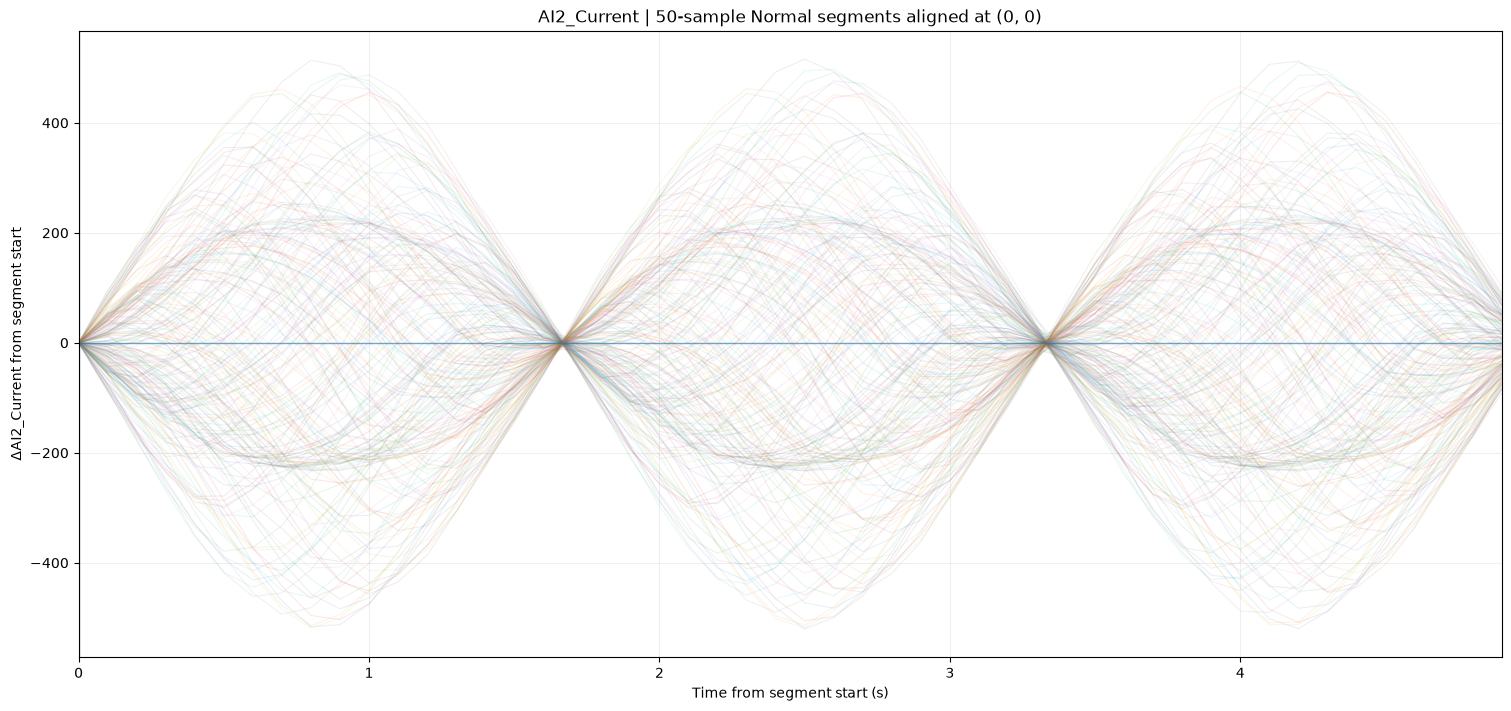

50-sample Normal segments : 202
Displayed trajectories    : 202
Alignment                 : t=0.0 s, ΔAI2_Current=0.0


In [5]:
# 길이가 정확히 50 samples인 모든 Normal segment의 AI2_Current를 한 그래프에 겹친다.
# 각 segment의 시작시간과 시작 AI2 값을 모두 빼서 모든 파형을 (0.0 s, 0.0)에 정렬한다.
# 따라서 절대 Current 수준 차이를 제거하고 4.9초 동안의 상대적인 파형 움직임만 비교한다.
# 약 1.7초 간격의 반복적인 상승·하강 구조가 여러 segment에서 공통적으로 나타나는지 시각적으로 확인한다.

SEGMENT_ROWS=50
CHANNEL="AI2_Current"

segments_50=[
    g.copy()
    for _,g in normal.groupby("segment_id",sort=False)
    if len(g)==SEGMENT_ROWS
]

if not segments_50:
    raise ValueError("50-sample Normal segment가 없음")

fig,ax=plt.subplots(figsize=(15,7),constrained_layout=True)

for group in segments_50:
    t=group["elapsed_sec"].to_numpy(float)
    y=group[CHANNEL].to_numpy(float)

    t=t-t[0]      # x축 시작점을 0.0초로 정렬
    y=y-y[0]      # y축 시작값을 0.0으로 정렬

    ax.plot(t,y,alpha=.10,lw=.8)

ax.axhline(0,lw=1,alpha=.6)
ax.axvline(0,lw=1,alpha=.6)

ax.set_title(f"{CHANNEL} | 50-sample Normal segments aligned at (0, 0)")
ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("ΔAI2_Current from segment start")
ax.set_xlim(0,4.9)
ax.grid(alpha=.2)

plt.show()

print(f"50-sample Normal segments : {len(segments_50)}")
print(f"Displayed trajectories    : {len(segments_50)}")
print("Alignment                 : t=0.0 s, ΔAI2_Current=0.0")

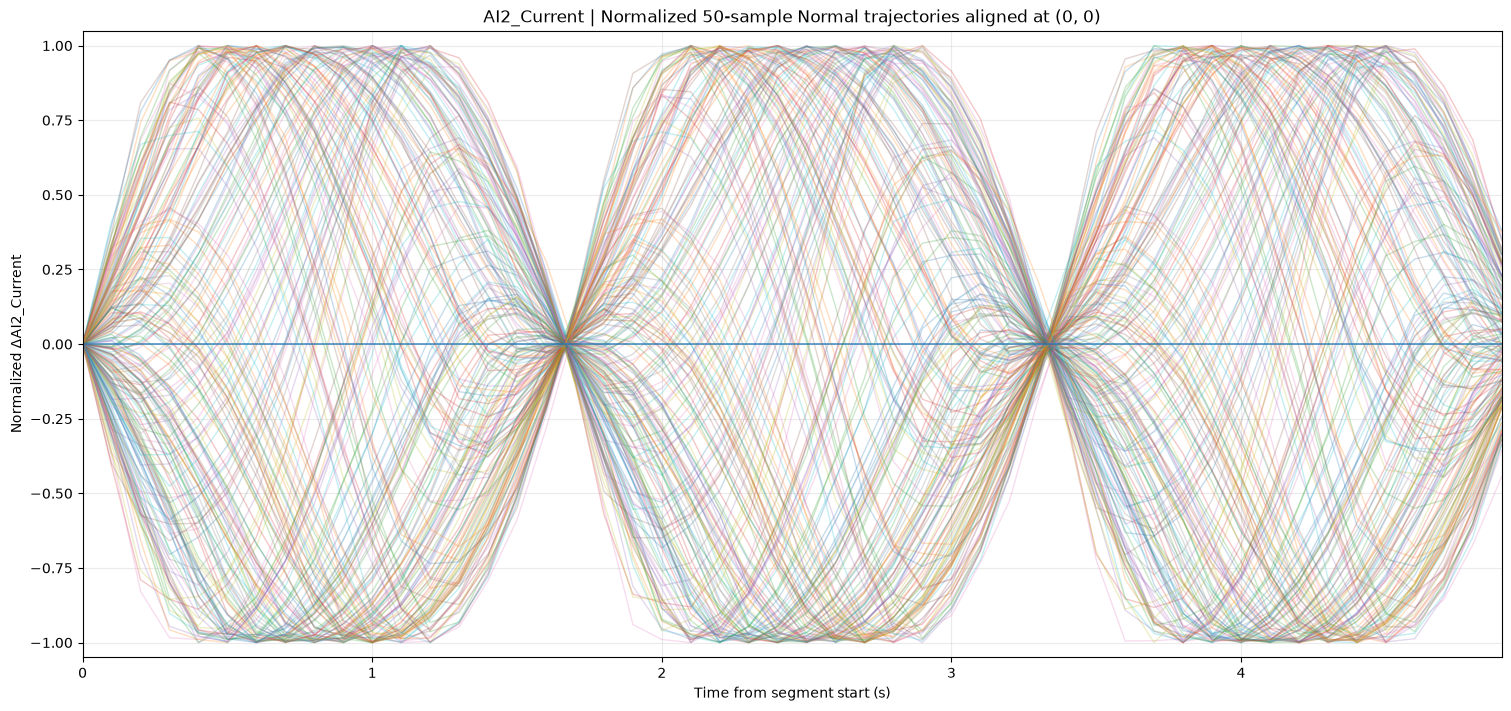

50-sample Normal segments : 202
Displayed trajectories    : 202
Alignment                 : (0.0 s, 0.0)
Normalization             : ΔAI2 / max(|ΔAI2|)


In [6]:
# 50-sample Normal segment의 AI2_Current를 모두 (0,0)에 정렬한다.
# 시작값을 제거한 뒤 각 segment의 최대 절대 변화량으로 나누어 진폭을 정규화한다.
# 따라서 절대 Current 크기보다 4.9초 동안 반복되는 파형의 상대적 움직임과 shape에 집중한다.
# 선의 투명도와 두께를 높여 수백 개 trajectory의 공통 궤적이 더 선명하게 보이도록 한다.

SEGMENT_ROWS=50
CHANNEL="AI2_Current"

segments_50=[
    g.copy()
    for _,g in normal.groupby("segment_id",sort=False)
    if len(g)==SEGMENT_ROWS
]

if not segments_50:
    raise ValueError("50-sample Normal segment가 없음")

fig,ax=plt.subplots(figsize=(15,7),constrained_layout=True)

n_plotted=0

for group in segments_50:
    t=group["elapsed_sec"].to_numpy(float)
    y=group[CHANNEL].to_numpy(float)

    # (0,0) 정렬
    t=t-t[0]
    y=y-y[0]

    # segment별 진폭 정규화
    scale=np.max(np.abs(y))
    if scale<=0:
        continue

    y_norm=y/scale

    ax.plot(t,y_norm,alpha=.25,lw=1.0)
    n_plotted+=1

ax.axhline(0,lw=1.2,alpha=.8)
ax.axvline(0,lw=1.2,alpha=.8)

ax.set_title("AI2_Current | Normalized 50-sample Normal trajectories aligned at (0, 0)")
ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("Normalized ΔAI2_Current")
ax.set_xlim(0,4.9)
ax.set_ylim(-1.05,1.05)
ax.grid(alpha=.25)

plt.show()

print(f"50-sample Normal segments : {len(segments_50)}")
print(f"Displayed trajectories    : {n_plotted}")
print("Alignment                 : (0.0 s, 0.0)")
print("Normalization             : ΔAI2 / max(|ΔAI2|)")

In [7]:
# 각 Normal segment에서 AI2_Current가 자기 자신과 가장 유사해지는 시간차를 찾는다.
# 0_Cycle의 Peak/ACF/PSD에서 확인된 약 1.6~1.7초 주변을 1.2~2.2초 범위로 넓게 탐색한다.
# 각 lag에서 원 신호와 lag만큼 이동한 신호의 상관계수를 계산하고 최대값을 반복주기 후보로 선택한다.
# 모든 계산은 공식 segment 내부에서만 수행하며 서로 다른 segment나 gap을 연결하지 않는다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE_INTERVAL=0.1
MIN_PERIOD_SEC=1.2
MAX_PERIOD_SEC=2.2

min_lag=int(MIN_PERIOD_SEC/SAMPLE_INTERVAL)
max_lag=int(MAX_PERIOD_SEC/SAMPLE_INTERVAL)

def estimate_period_acf(group):
    y=group["AI2_Current"].to_numpy(dtype=float)

    # 최대 탐색 lag보다 짧은 segment는 반복주기 판단에서 제외
    if len(y)<=max_lag:
        return np.nan,np.nan

    # 평균 제거
    y=y-np.mean(y)

    # 변화가 없는 신호 제외
    if np.std(y)==0:
        return np.nan,np.nan

    acf_values=[]

    for lag in range(min_lag,max_lag+1):
        x1=y[:-lag]
        x2=y[lag:]

        # 비교 가능한 sample이 너무 적은 경우 제외
        if len(x1)<5 or np.std(x1)==0 or np.std(x2)==0:
            acf_values.append(np.nan)
            continue

        acf_values.append(np.corrcoef(x1,x2)[0,1])

    acf_values=np.asarray(acf_values,dtype=float)

    if np.all(np.isnan(acf_values)):
        return np.nan,np.nan

    best_idx=np.nanargmax(acf_values)
    best_lag=min_lag+best_idx
    best_corr=acf_values[best_idx]

    return best_lag*SAMPLE_INTERVAL,best_corr

In [8]:
# 앞에서 정의한 반복주기 추정 함수를 모든 Normal segment에 적용한다.
# 각 segment마다 반복주기 후보와 해당 lag의 상관계수를 저장한다.
# 공식 데이터의 segment 등장 순서를 유지하며 서로 다른 segment는 절대 연결하지 않는다.
# 계산 가능한 segment 수와 전체 대비 비율을 확인하여 이후 주기 분포 검증에 사용한다.

period_results=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    period_sec,acf_corr=estimate_period_acf(group)

    period_results.append({
        "segment_id":segment_id,
        "n_samples":len(group),
        "period_sec":period_sec,
        "acf_corr":acf_corr
    })

period_df=pd.DataFrame(period_results)

total_segments=normal["segment_id"].nunique()
valid_segments=period_df["period_sec"].notna().sum()

display(period_df.head())

print(f"전체 Normal segments     : {total_segments}")
print(f"주기 계산 가능 segments : {valid_segments}")
print(f"계산 가능 비율           : {valid_segments/total_segments:.1%}")

,segment_id,n_samples,period_sec,acf_corr
0,N0000,41,1.7,0.991380
1,N0001,37,1.7,0.993755
2,N0002,24,1.7,0.997951
3,N0003,10,NaN,NaN
4,N0004,50,1.7,0.992062


전체 Normal segments     : 599
주기 계산 가능 segments : 424
계산 가능 비율           : 70.8%


In [9]:
# 반복주기를 계산할 수 있었던 Normal segment만 사용하여 결과를 요약한다.
# 반복주기의 중심과 분산을 확인하여 segment별 추정값이 특정 주기에 집중되는지 평가한다.
# ACF correlation도 함께 확인하여 선택된 반복주기에서 실제 자기유사성이 얼마나 강한지 검증한다.
# 다음 단계에서는 1.6~1.7초 구간의 집중 비율과 전체 분포를 직접 확인한다.

valid_period=period_df.dropna(subset=["period_sec","acf_corr"]).copy()

period_summary=pd.Series({
    "segments":len(valid_period),
    "period_mean_sec":valid_period["period_sec"].mean(),
    "period_std_sec":valid_period["period_sec"].std(),
    "period_Q1_sec":valid_period["period_sec"].quantile(.25),
    "period_median_sec":valid_period["period_sec"].median(),
    "period_Q3_sec":valid_period["period_sec"].quantile(.75),
    "period_min_sec":valid_period["period_sec"].min(),
    "period_max_sec":valid_period["period_sec"].max(),
    "ACF_mean":valid_period["acf_corr"].mean(),
    "ACF_median":valid_period["acf_corr"].median()
},name="Normal AI2 periodicity")

display(period_summary.to_frame())

,Normal AI2 periodicity
segments,424.000000
period_mean_sec,1.699528
period_std_sec,0.006860
period_Q1_sec,1.700000
period_median_sec,1.700000
period_Q3_sec,1.700000
period_min_sec,1.600000
period_max_sec,1.700000
ACF_mean,0.991295
ACF_median,0.991877


In [10]:
# 각 Normal segment가 선택한 최적 반복주기가 어느 값에 집중되는지 확인한다.
# 저장 간격이 약 0.1초이므로 반복주기 후보 역시 0.1초 단위로 나타난다.
# 각 주기를 선택한 segment의 개수와 계산 가능한 segment 내 비율을 함께 계산한다.
# 특히 1.6~1.7초 부근에 결과가 집중되는지가 핵심 확인 대상이다.

period_counts=(
    valid_period["period_sec"]
    .round(1)
    .value_counts()
    .sort_index()
)

period_distribution=pd.DataFrame({
    "segment_count":period_counts,
    "ratio":period_counts/len(valid_period)
})

period_distribution.index.name="period_sec"

display(period_distribution)

,segment_count,ratio
period_sec,,
1.6,2,0.004717
1.7,422,0.995283


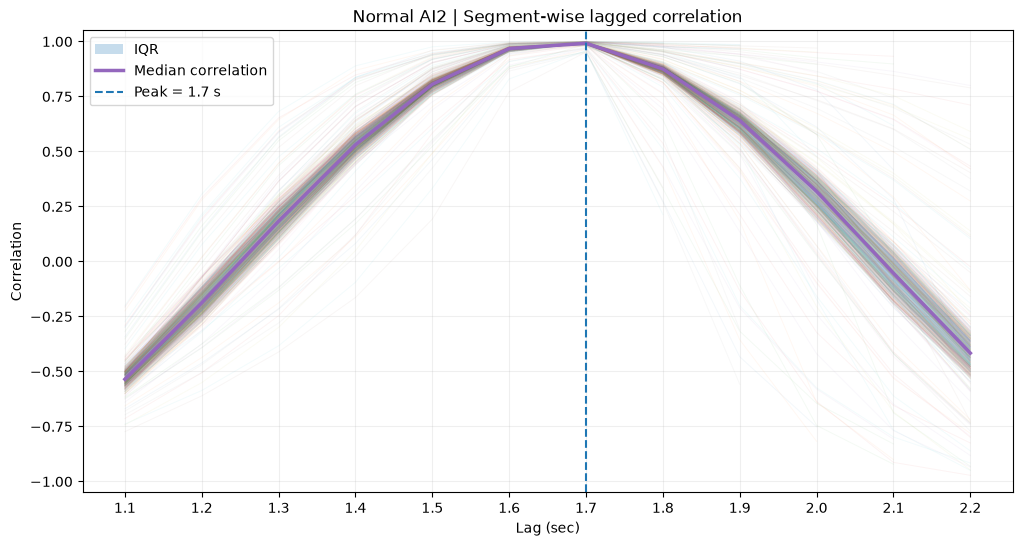

Analyzed segments          : 424
Median correlation peak    : 1.7 s
Median correlation at peak : 0.9919
Segments selecting peak    : 99.5%


In [13]:
# 각 Normal segment에서 1.2~2.2초의 lag별 AI2 자기유사성을 직접 비교한다.
# 최종 선택된 주기의 빈도보다 1.7초에서 correlation이 실제로 가장 강한지를 확인한다.
# 개별 segment의 profile을 겹치고 Median + IQR을 표시하여 반복구조의 안정성을 시각화한다.
# 따라서 1.7초가 단순히 선택된 값이 아니라 주변 lag 대비 뚜렷한 최대점인지 검증한다.

lags=np.arange(min_lag,max_lag+1)
lag_sec=lags*SAMPLE_INTERVAL
acf_profiles=[]

for _,group in normal.groupby("segment_id",sort=False):
    y=group["AI2_Current"].to_numpy(float)

    if len(y)<=max_lag:
        continue

    y=y-y.mean()
    if np.std(y)==0:
        continue

    profile=[]
    for lag in lags:
        x1=y[:-lag]
        x2=y[lag:]

        if len(x1)<5 or np.std(x1)==0 or np.std(x2)==0:
            profile.append(np.nan)
        else:
            profile.append(np.corrcoef(x1,x2)[0,1])

    acf_profiles.append(profile)

acf_profiles=np.asarray(acf_profiles,float)

median_acf=np.nanmedian(acf_profiles,axis=0)
q1_acf=np.nanquantile(acf_profiles,.25,axis=0)
q3_acf=np.nanquantile(acf_profiles,.75,axis=0)

best_idx=np.nanargmax(median_acf)
best_period=lag_sec[best_idx]

fig,ax=plt.subplots(figsize=(12,6))

for profile in acf_profiles:
    ax.plot(lag_sec,profile,alpha=.05,lw=.7)

ax.fill_between(
    lag_sec,q1_acf,q3_acf,
    alpha=.25,label="IQR"
)

ax.plot(
    lag_sec,median_acf,
    lw=2.5,label="Median correlation"
)

ax.axvline(
    best_period,
    linestyle="--",
    lw=1.5,
    label=f"Peak = {best_period:.1f} s"
)

ax.set_title("Normal AI2 | Segment-wise lagged correlation")
ax.set_xlabel("Lag (sec)")
ax.set_ylabel("Correlation")
ax.set_xticks(lag_sec)
ax.set_ylim(-1.05,1.05)
ax.grid(alpha=.2)
ax.legend()

plt.show()

best_ratio=(
    valid_period["period_sec"].round(1)==round(best_period,1)
).mean()

print(f"Analyzed segments          : {len(acf_profiles)}")
print(f"Median correlation peak    : {best_period:.1f} s")
print(f"Median correlation at peak : {median_acf[best_idx]:.4f}")
print(f"Segments selecting peak    : {best_ratio:.1%}")

In [14]:
# 개별 Normal segment의 반복주기 후보가 1.6~1.7초에 얼마나 집중되는지 정량화한다.
# 1.6~1.7초는 앞선 Peak/ACF/PSD 분석에서 반복적으로 확인된 AI2 반복주기 후보 범위이다.
# 0.1초 시간해상도에 맞춰 period를 소수 첫째 자리로 정리한 뒤 해당 범위의 비율을 계산한다.
# 이 값은 그래프 대신 반복주기의 segment 간 재현성을 숫자로 요약하는 지표로 사용한다.

period_rounded=valid_period["period_sec"].round(1)
target_mask=period_rounded.between(1.6,1.7,inclusive="both")

target_count=int(target_mask.sum())
total_count=len(valid_period)
target_ratio=target_mask.mean()

print(f"1.6~1.7 s segments : {target_count} / {total_count}")
print(f"Ratio               : {target_ratio:.1%}")

1.6~1.7 s segments : 424 / 424
Ratio               : 100.0%


# 마지막 검증 : Segment 시작 위상 검증

## ② Segment 시작 위상 검증

### 목적

Normal 데이터는 Gap에 의해 여러 개의 독립적인 연속구간(segment)으로 분리되어 있다.

앞선 분석에서 각 segment의 시작점을 기준으로 AI2_Current를 정렬했을 때,
약 1.6~1.7초 반복구조뿐 아니라 파형의 시작 형태도 서로 유사하게 나타나는 현상이 관찰되었다.

따라서 각 segment의 첫 관측점이 AI2 반복파형의 다양한 위상에 분포하는지,
아니면 특정한 유사 위상에 집중되는 경향이 있는지 검증한다.

이를 통해 다음 두 현상을 구분한다.

- 반복주기만 약 1.6~1.7초로 동일하고 segment 시작 위상은 서로 다름
- 반복주기뿐 아니라 segment 시작점도 유사한 위상에 정렬됨

※ Segment 시작점을 실제 프레스 공정의 시작점으로 가정하지 않는다.  
※ Segment 시작 위상의 정렬이 확인되더라도 이를 공정 Cycle 시작점이라고 해석하지 않는다.  
※ Gap 발생 원인 및 데이터 수집 시스템의 동작 방식은 제공된 정보만으로 확정하지 않는다.

In [15]:
# 각 Normal segment의 시작점과 약 1.7초 후 AI2_Current 값을 비교한다.
# 10 Hz 기준 17 samples 뒤 신호가 시작 수준으로 얼마나 복귀하는지 Return Error로 계산한다.
# segment마다 진폭이 다르므로 절대오차를 해당 segment의 전체 signal range로 정규화한다.
# 이 결과만으로 동일 시작 위상을 확정하지 않고 이후 다른 lag와 비교하여 1.7초 복귀의 특이성을 검증한다.

PHASE_PERIOD_SAMPLES=17

phase_results=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    y=group["AI2_Current"].to_numpy(dtype=float)

    if len(y)<=PHASE_PERIOD_SAMPLES:
        continue

    start_value=y[0]
    return_value=y[PHASE_PERIOD_SAMPLES]
    delta=return_value-start_value
    signal_range=np.ptp(y)

    normalized_return_error=(
        abs(delta)/signal_range
        if signal_range>0 else np.nan
    )

    phase_results.append({
        "segment_id":segment_id,
        "n_samples":len(y),
        "start_value":start_value,
        "value_1_7s":return_value,
        "delta_1_7s":delta,
        "abs_delta_1_7s":abs(delta),
        "signal_range":signal_range,
        "normalized_return_error":normalized_return_error
    })

phase_df=pd.DataFrame(phase_results)

print(f"Comparable segments : {len(phase_df)}")
display(phase_df.head())

Comparable segments : 463


,segment_id,n_samples,start_value,value_1_7s,delta_1_7s,abs_delta_1_7s,signal_range,normalized_return_error
0,N0000,41,192.338730,208.763390,16.424660,16.424660,439.24885,0.037393
1,N0001,37,28.972868,9.004713,-19.968155,19.968155,433.55648,0.046057
2,N0002,24,-109.878910,-107.645170,2.233740,2.233740,220.65249,0.010123
3,N0004,50,58.613784,45.624619,-12.989165,12.989165,221.60950,0.058613
4,N0005,50,106.054200,128.975880,22.921680,22.921680,449.98281,0.050939


In [16]:
# 1.7초 후 AI2_Current가 segment 시작값으로 얼마나 복귀하는지 수치로 요약한다.
# 절대 Return Error는 원 신호 단위의 차이를, Normalized Return Error는 segment 진폭 대비 차이를 의미한다.
# segment마다 진폭 크기가 다르므로 이후 비교에서는 Normalized Return Error를 주 지표로 사용한다.
# Median과 IQR을 중심으로 1.7초 복귀 오차의 대표적인 크기와 분산을 확인한다.

return_summary=pd.DataFrame({
    "absolute_return_error":phase_df["abs_delta_1_7s"].describe()[["count","mean","25%","50%","75%","std"]],
    "normalized_return_error":phase_df["normalized_return_error"].describe()[["count","mean","25%","50%","75%","std"]]
})

display(return_summary)

print(f"Median absolute return error   : {phase_df['abs_delta_1_7s'].median():.6f}")
print(f"Median normalized return error : {phase_df['normalized_return_error'].median():.6f}")

,absolute_return_error,normalized_return_error
count,463.000000,463.000000
mean,13.444060,0.039374
25%,6.257655,0.023171
50%,12.733580,0.038953
75%,19.175891,0.054954
std,8.578894,0.021802


Median absolute return error   : 12.733580
Median normalized return error : 0.038953


In [19]:
# 0.5~2.0초의 여러 lag에서 Segment 시작값으로 돌아오는 정도를 동일 조건으로 비교한다.
# 모든 lag가 같은 Normal segment 집합을 사용하도록 최대 lag까지 존재하는 segment만 사용한다.
# Return Error를 segment 전체 AI2 range로 정규화하여 amplitude 차이의 영향을 줄인다.
# 1.7초에서 오차가 뚜렷하게 낮은지 확인하여 반복주기 후보를 별도 방식으로 검증한다.

SAMPLE_INTERVAL=0.1
SAMPLE_RATE_HZ=1/SAMPLE_INTERVAL

TEST_LAGS=[5,8,10,17,20]
MAX_TEST_LAG=max(TEST_LAGS)

eligible_groups=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    y=group["AI2_Current"].to_numpy(float)

    if len(y)<=MAX_TEST_LAG:
        continue

    signal_range=np.ptp(y)

    if signal_range<=0:
        continue

    eligible_groups.append((segment_id,y,signal_range))

lag_results=[]

for lag in TEST_LAGS:
    errors=[]

    for _,y,signal_range in eligible_groups:
        error=abs(y[lag]-y[0])/signal_range
        errors.append(error)

    errors=np.asarray(errors,float)

    lag_results.append({
        "lag_samples":lag,
        "lag_sec":lag*SAMPLE_INTERVAL,
        "n_segments":len(errors),
        "median_return_error":np.median(errors),
        "q25_return_error":np.quantile(errors,.25),
        "q75_return_error":np.quantile(errors,.75)
    })

lag_df=pd.DataFrame(lag_results)

display(lag_df)

print(f"Common comparable segments : {len(eligible_groups)}")

,lag_samples,lag_sec,n_segments,median_return_error,q25_return_error,q75_return_error
0,5,0.5,444,0.573068,0.291897,0.728362
1,8,0.8,444,0.715310,0.376678,0.921499
2,10,1.0,444,0.672951,0.371309,0.873058
3,17,1.7,444,0.038842,0.022485,0.054927
4,20,2.0,444,0.404806,0.216549,0.516200


Common comparable segments : 444


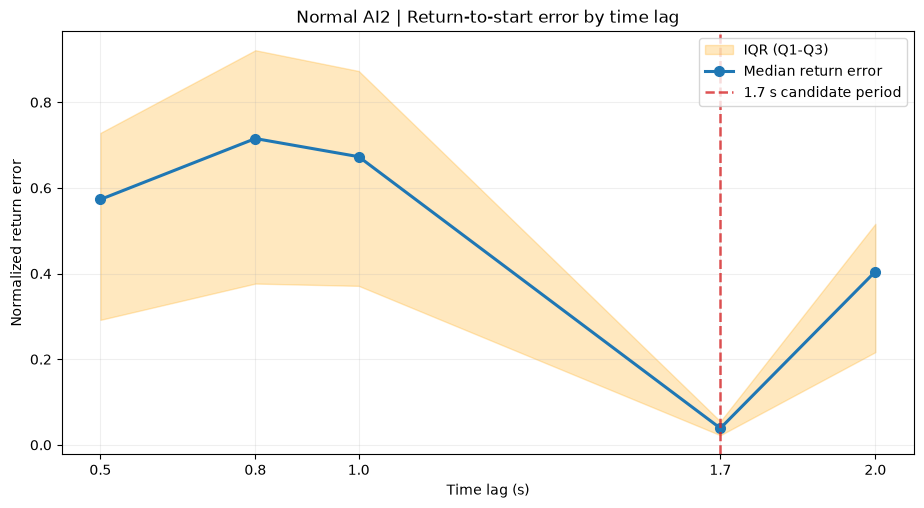

In [21]:
# 여러 시간 lag에서 AI2의 Return-to-start Error를 비교한다.
# 파란 선은 Median, 주황 음영은 IQR(Q1~Q3)로 segment 간 분산을 나타낸다.
# 빨간 점선은 앞선 분석에서 확인한 약 1.7초 반복주기 후보를 표시한다.
# 1.7초에서 Median과 IQR이 함께 낮아지는지가 핵심 확인 대상이다.

x=lag_df["lag_sec"].to_numpy(float)
median=lag_df["median_return_error"].to_numpy(float)
q25=lag_df["q25_return_error"].to_numpy(float)
q75=lag_df["q75_return_error"].to_numpy(float)

fig,ax=plt.subplots(figsize=(11,5.5))

ax.fill_between(
    x,q25,q75,
    color="orange",
    alpha=.25,
    label="IQR (Q1-Q3)"
)

ax.plot(
    x,median,
    color="tab:blue",
    marker="o",
    markersize=7,
    linewidth=2.2,
    label="Median return error"
)

ax.axvline(
    1.7,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    alpha=.8,
    label="1.7 s candidate period"
)

ax.set_title("Normal AI2 | Return-to-start error by time lag")
ax.set_xlabel("Time lag (s)")
ax.set_ylabel("Normalized return error")
ax.set_xticks(x)

ax.grid(alpha=.2)
ax.legend(
    loc="upper right",
    frameon=True
)

plt.show()

=== Baseline Reproduction ===
 window  distance  prom  normal_cycles  normal_segments  duration_med  duration_q25  duration_q75  ratio_1.6_1.7  holdout_n  shape_th  holdout_rmse_med  holdout_fpr  abnormal_cycles  abnormal_segments  abnormal_breaks  abnormal_break_rate  baseline
      3        12   0.5            475              338           1.7           1.6           1.7            1.0        154    0.1813             0.077        0.039                8                  6                8                  1.0      True

=== Parameter Sensitivity : All 27 Combinations ===
 window  distance  prom  normal_cycles  normal_segments  duration_med  duration_q25  duration_q75  ratio_1.6_1.7  holdout_fpr  abnormal_cycles  abnormal_breaks  abnormal_break_rate
      1        10   0.4            516              344           1.7           1.6           1.7         0.9864       0.0118               22               22                  1.0
      1        10   0.5            504              343  

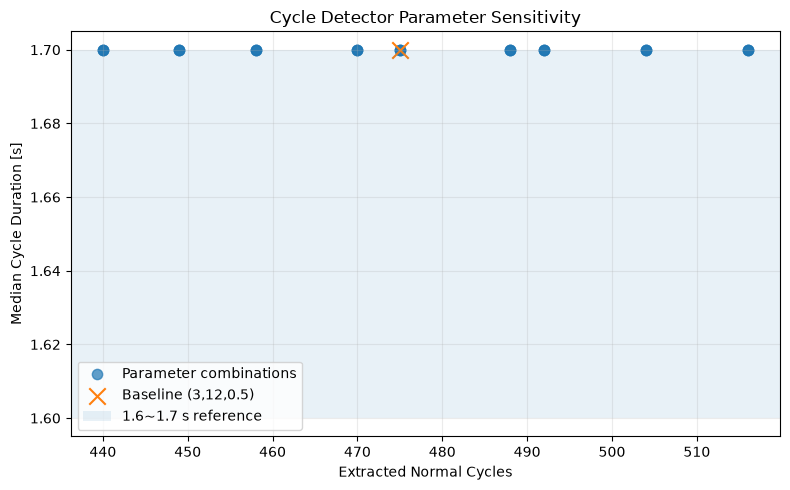

In [1]:
# Peak detector 27개 조합에서 약 1.7초 Cycle 결론의 민감도를 검증한다.
# Normal cycle 수·duration·shape FPR과 Abnormal shape break를 동시에 비교한다.
# Normal segment를 고정 Train/Holdout으로 나눠 threshold leakage를 방지한다.
# 기준 설정은 window=3, distance=12, prominence=0.5이며 최적화가 목적은 아니다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from itertools import product

WINDOWS, DISTANCES, PROMS = [1, 3, 5], [10, 12, 14], [.4, .5, .6]
MIN_SEG_ROWS, N_PHASE, SHAPE_Q = 30, 32, .99
BASELINE = (3, 12, .5)

# 기존 notebook의 official preprocessed data를 우선 사용한다.
if "data" not in globals():
    from pathlib import Path
    p = Path.cwd()
    while not (p / "data/processed/preprocessed_data.csv").exists() and p != p.parent: p = p.parent
    data = pd.read_csv(p / "data/processed/preprocessed_data.csv")

normal = data[data["source"] == "normal"].copy()
abnormal = data[data["source"] == "abnormal"].copy()

# 모든 parameter 조합에서 동일한 Normal segment Train/Holdout을 사용한다.
segments = normal["segment_id"].unique()
train_seg, holdout_seg = train_test_split(segments, test_size=.30, random_state=42)
train_seg, holdout_seg = set(train_seg), set(holdout_seg)

def phase_shape(x):
    x = np.asarray(x, float)
    y = np.interp(np.linspace(0, 1, N_PHASE), np.linspace(0, 1, len(x)), x)
    sd = y.std(ddof=1)
    return None if sd == 0 else (y - y.mean()) / sd

def extract_cycles(df, source, window, distance, prom_factor):
    meta, shapes = [], []

    for seg, g in df[df["source"] == source].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g["AI2_Current"].to_numpy(float)
        sm = pd.Series(cur).rolling(window, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(sm, ddof=1) * prom_factor, np.finfo(float).eps)
        peaks, _ = find_peaks(sm, distance=distance, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < distance: continue
            c = g.iloc[s:e + 1]
            duration = c["elapsed_sec"].iloc[-1] - c["elapsed_sec"].iloc[0]
            shape = phase_shape(c["AI2_Current"])
            if duration <= 0 or shape is None: continue

            meta.append({
                "segment_id": seg, "cycle_id": cid,
                "duration_sec": float(duration)
            })
            shapes.append(shape)

    return pd.DataFrame(meta), np.vstack(shapes) if shapes else np.empty((0, N_PHASE))

def evaluate_combo(window, distance, prom):
    nm, ns = extract_cycles(data, "normal", window, distance, prom)
    am, a_s = extract_cycles(data, "abnormal", window, distance, prom)

    if len(nm) == 0: return None

    tr = nm["segment_id"].isin(train_seg).to_numpy()
    ho = nm["segment_id"].isin(holdout_seg).to_numpy()
    tr_s, ho_s = ns[tr], ns[ho]

    if len(tr_s) == 0 or len(ho_s) == 0: return None

    template = tr_s.mean(axis=0)
    template = (template - template.mean()) / template.std(ddof=1)

    tr_rmse = np.sqrt(np.mean((tr_s - template) ** 2, axis=1))
    ho_rmse = np.sqrt(np.mean((ho_s - template) ** 2, axis=1))
    ab_rmse = np.sqrt(np.mean((a_s - template) ** 2, axis=1)) if len(a_s) else np.array([])

    th = np.quantile(tr_rmse, SHAPE_Q)
    d = nm["duration_sec"].round(1)

    return {
        "window": window, "distance": distance, "prom": prom,
        "normal_cycles": len(nm), "normal_segments": nm["segment_id"].nunique(),
        "duration_med": nm["duration_sec"].median(),
        "duration_q25": nm["duration_sec"].quantile(.25),
        "duration_q75": nm["duration_sec"].quantile(.75),
        "ratio_1.6_1.7": d.between(1.6, 1.7).mean(),
        "holdout_n": len(ho_rmse), "shape_th": th,
        "holdout_rmse_med": np.median(ho_rmse),
        "holdout_fpr": np.mean(ho_rmse > th),
        "abnormal_cycles": len(am),
        "abnormal_segments": am["segment_id"].nunique() if len(am) else 0,
        "abnormal_breaks": int(np.sum(ab_rmse > th)),
        "abnormal_break_rate": np.mean(ab_rmse > th) if len(ab_rmse) else np.nan
    }

rows = [evaluate_combo(*p) for p in product(WINDOWS, DISTANCES, PROMS)]
result = pd.DataFrame([r for r in rows if r is not None])
result["baseline"] = (
    (result.window == BASELINE[0]) &
    (result.distance == BASELINE[1]) &
    np.isclose(result.prom, BASELINE[2])
)

print("=== Baseline Reproduction ===")
print(result[result.baseline].round(4).to_string(index=False))

print("\n=== Parameter Sensitivity : All 27 Combinations ===")
cols = ["window", "distance", "prom", "normal_cycles", "normal_segments",
        "duration_med", "duration_q25", "duration_q75", "ratio_1.6_1.7",
        "holdout_fpr", "abnormal_cycles", "abnormal_breaks", "abnormal_break_rate"]
print(result[cols].round(4).to_string(index=False))

print("\n=== Robustness Range ===")
for c in ["normal_cycles", "normal_segments", "duration_med", "ratio_1.6_1.7",
          "holdout_fpr", "abnormal_cycles", "abnormal_break_rate"]:
    print(f"{c:20s}: {result[c].min():.4f} ~ {result[c].max():.4f}")

# Parameter 변화에도 1.7초 및 Shape 결론이 얼마나 유지되는지 요약한다.
stable = (
    result["duration_med"].between(1.6, 1.7) &
    (result["ratio_1.6_1.7"] >= .90) &
    (result["holdout_fpr"] <= .05) &
    (result["abnormal_break_rate"] >= .75)
)

print("\n=== Overall Robustness ===")
print(f"Stable combinations : {stable.sum()} / {len(result)}")
print(f"Stable ratio        : {stable.mean():.1%}")

# 시각화: detector 설정이 바뀌어도 duration과 abnormal break가 유지되는지 확인한다.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(result["normal_cycles"], result["duration_med"], s=55, alpha=.7, label="Parameter combinations")
base = result[result.baseline]
ax.scatter(base["normal_cycles"], base["duration_med"], marker="x", s=140, label="Baseline (3,12,0.5)")
ax.axhspan(1.6, 1.7, alpha=.1, label="1.6~1.7 s reference")
ax.set_xlabel("Extracted Normal Cycles")
ax.set_ylabel("Median Cycle Duration [s]")
ax.set_title("Cycle Detector Parameter Sensitivity")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

=== Canonical Baseline Abnormal Cycles ===
Canonical cycles : 8
Shape threshold  : 0.1895
segment_id  cycle_id  duration_sec  canonical_rmse  canonical_break
     A0001         1           1.3          0.8628             True
     A0001         2           1.3          1.2401             True
     A0006         1           1.5          0.5603             True
     A0011         1           1.6          1.5245             True
     A0011         2           1.6          1.2381             True
     A0012         1           1.9          1.5836             True
     A0016         1           1.2          1.0792             True
     A0017         1           1.6          1.0329             True

=== Canonical Matching Sensitivity ===
 window  distance  prom  canonical_n  matched_n  median_iou  min_iou  shape_breaks  match_rate  break_rate_all  break_rate_matched  baseline
      1        10   0.4            8          6      0.8167   0.3636             6       0.750           0.750       

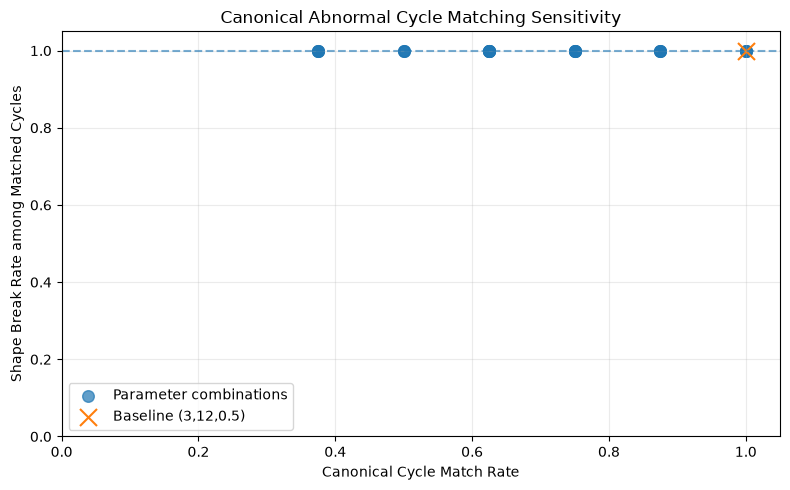

In [2]:
# Baseline에서 추출된 8개 Abnormal Cycle을 Canonical Cycle로 고정한다.
# 다른 27개 detector 조합에서 같은 segment·시간구간의 Cycle을 IoU로 매칭한다.
# 매칭된 동일 구간이 고정된 Normal Shape 기준에서도 계속 이상인지 검증한다.
# detector가 다른 abnormal cycle을 골라서 100%가 된 것인지 구분하는 마지막 robustness test다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from itertools import product

WINDOWS, DISTANCES, PROMS = [1,3,5], [10,12,14], [.4,.5,.6]
BASELINE, MIN_SEG_ROWS, N_PHASE, SHAPE_Q, MIN_IOU = (3,12,.5), 30, 32, .99, .50

if "data" not in globals():
    from pathlib import Path
    p=Path.cwd()
    while not (p/"data/processed/preprocessed_data.csv").exists() and p!=p.parent: p=p.parent
    data=pd.read_csv(p/"data/processed/preprocessed_data.csv")

def phase_shape(x):
    x=np.asarray(x,float)
    y=np.interp(np.linspace(0,1,N_PHASE),np.linspace(0,1,len(x)),x)
    sd=y.std(ddof=1)
    return None if sd==0 else (y-y.mean())/sd

def extract_cycles(source,window,distance,prom_factor):
    rows,shapes=[],[]
    for seg,g in data[data.source==source].groupby("segment_id",sort=False):
        g=g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g)<MIN_SEG_ROWS: continue

        cur=g.AI2_Current.to_numpy(float)
        sm=pd.Series(cur).rolling(window,center=True,min_periods=1).median().to_numpy()
        prom=max(np.std(sm,ddof=1)*prom_factor,np.finfo(float).eps)
        peaks,_=find_peaks(sm,distance=distance,prominence=prom)

        for cid,(s,e) in enumerate(zip(peaks[:-1],peaks[1:]),1):
            if e-s<distance: continue
            c=g.iloc[s:e+1]
            duration=c.elapsed_sec.iloc[-1]-c.elapsed_sec.iloc[0]
            shape=phase_shape(c.AI2_Current)
            if duration<=0 or shape is None: continue
            rows.append({"segment_id":seg,"cycle_id":cid,"start_pos":s,"end_pos":e,
                         "start_sec":float(c.elapsed_sec.iloc[0]),"end_sec":float(c.elapsed_sec.iloc[-1]),
                         "duration_sec":float(duration)})
            shapes.append(shape)

    return pd.DataFrame(rows),np.vstack(shapes) if shapes else np.empty((0,N_PHASE))

def interval_iou(a0,a1,b0,b1):
    inter=max(0,min(a1,b1)-max(a0,b0))
    union=max(a1,b1)-min(a0,b0)
    return inter/union if union>0 else 0

# 1. Baseline Normal에서 고정 Shape Reference 생성
normal_base,normal_shape=extract_cycles("normal",*BASELINE)
segments=normal_base.segment_id.unique()
train_seg,holdout_seg=train_test_split(segments,test_size=.30,random_state=42)
tr=normal_base.segment_id.isin(set(train_seg)).to_numpy()

template=normal_shape[tr].mean(axis=0)
template=(template-template.mean())/template.std(ddof=1)
train_rmse=np.sqrt(np.mean((normal_shape[tr]-template)**2,axis=1))
SHAPE_TH=np.quantile(train_rmse,SHAPE_Q)

# 2. Baseline Abnormal 8개를 Canonical Cycle로 고정
canonical,canonical_shape=extract_cycles("abnormal",*BASELINE)
canonical=canonical.reset_index(drop=True)
canonical["canonical_rmse"]=np.sqrt(np.mean((canonical_shape-template)**2,axis=1))
canonical["canonical_break"]=canonical.canonical_rmse>SHAPE_TH

print("=== Canonical Baseline Abnormal Cycles ===")
print(f"Canonical cycles : {len(canonical)}")
print(f"Shape threshold  : {SHAPE_TH:.4f}")
print(canonical[["segment_id","cycle_id","duration_sec","canonical_rmse","canonical_break"]].round(4).to_string(index=False))

# 3. 모든 detector 조합에서 Canonical 8개와 같은 시간구간 Cycle 매칭
match_rows=[]

for window,distance,prom in product(WINDOWS,DISTANCES,PROMS):
    cand,cand_shape=extract_cycles("abnormal",window,distance,prom)

    for k,base in canonical.iterrows():
        same=cand[cand.segment_id==base.segment_id]
        best_idx,best_iou=None,0

        for idx,r in same.iterrows():
            iou=interval_iou(base.start_sec,base.end_sec,r.start_sec,r.end_sec)
            if iou>best_iou: best_idx,best_iou=idx,iou

        matched=best_idx is not None and best_iou>=MIN_IOU
        rmse=np.nan
        is_break=False
        duration=np.nan

        if matched:
            rmse=float(np.sqrt(np.mean((cand_shape[best_idx]-template)**2)))
            duration=float(cand.loc[best_idx,"duration_sec"])
            is_break=rmse>SHAPE_TH

        match_rows.append({
            "window":window,"distance":distance,"prom":prom,
            "canonical_id":f"{base.segment_id}-{int(base.cycle_id)}",
            "segment_id":base.segment_id,"baseline_duration":base.duration_sec,
            "matched":matched,"iou":best_iou if best_idx is not None else 0,
            "matched_duration":duration,"shape_rmse":rmse,"shape_break":is_break
        })

matches=pd.DataFrame(match_rows)

# 4. 조합별 Robustness 요약
summary=(matches.groupby(["window","distance","prom"])
         .agg(canonical_n=("canonical_id","size"),
              matched_n=("matched","sum"),
              median_iou=("iou","median"),
              min_iou=("iou","min"),
              shape_breaks=("shape_break","sum"))
         .reset_index())

summary["match_rate"]=summary.matched_n/summary.canonical_n
summary["break_rate_all"]=summary.shape_breaks/summary.canonical_n
summary["break_rate_matched"]=summary.shape_breaks/summary.matched_n.replace(0,np.nan)
summary["baseline"]=(summary.window==3)&(summary.distance==12)&np.isclose(summary.prom,.5)

print("\n=== Canonical Matching Sensitivity ===")
print(summary.round(4).to_string(index=False))

print("\n=== Robustness Range ===")
for c in ["matched_n","match_rate","median_iou","shape_breaks","break_rate_all","break_rate_matched"]:
    print(f"{c:20s}: {summary[c].min():.4f} ~ {summary[c].max():.4f}")

print("\n=== Overall Result ===")
print(f"All canonical cycles matched in : {(summary.matched_n==len(canonical)).sum()} / {len(summary)} combinations")
print(f"All matched cycles shape-break  : {(summary.break_rate_matched==1).sum()} / {len(summary)} combinations")

# 5. Canonical Cycle별 얼마나 자주 다시 매칭되고 Shape Break가 유지되는지 확인
per_cycle=(matches.groupby("canonical_id")
           .agg(match_count=("matched","sum"),
                break_count=("shape_break","sum"),
                median_iou=("iou","median"),
                median_rmse=("shape_rmse","median"))
           .reset_index())

per_cycle["match_rate"]=per_cycle.match_count/len(summary)
per_cycle["break_rate_all"]=per_cycle.break_count/len(summary)
per_cycle["break_rate_when_matched"]=per_cycle.break_count/per_cycle.match_count.replace(0,np.nan)

print("\n=== Per Canonical Cycle Robustness ===")
print(per_cycle.round(4).to_string(index=False))

# 6. 시각화
plt.figure(figsize=(8,5))
plt.scatter(summary.match_rate,summary.break_rate_matched,s=70,alpha=.7,label="Parameter combinations")
base=summary[summary.baseline]
plt.scatter(base.match_rate,base.break_rate_matched,marker="x",s=150,label="Baseline (3,12,0.5)")
plt.axhline(1,linestyle="--",alpha=.6)
plt.xlabel("Canonical Cycle Match Rate")
plt.ylabel("Shape Break Rate among Matched Cycles")
plt.title("Canonical Abnormal Cycle Matching Sensitivity")
plt.xlim(0,1.05); plt.ylim(0,1.05)
plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()